## Customer Review Analysis

**Business Question**

What are the primary drivers of customer satisfaction and dissatisfaction, and what business improvements can be identified from customer feedback?

**Objectives**

- Investigate review scores
- Analyze review comments
- Identify common complaint categories
- Quantify delivery-related complaints
- Quantify product-related complaints
- Produce business recommendations

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if (Path.cwd() / "data" / "raw").exists():
    DATA_PATH = Path.cwd() / "data" / "raw"
elif (Path.cwd().parent / "data" / "raw").exists():
    DATA_PATH = Path.cwd().parent / "data" / "raw"
else:
    raise FileNotFoundError("Could not find the data/raw folder.")

reviews = pd.read_csv(
    DATA_PATH / "olist_order_reviews_dataset.csv"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [2]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [3]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

#### Confidence Level: High

The dataset contains substantial missing review text, but every review includes a review score and supporting metadata. The available comments provide a sufficiently large sample to investigate common customer issues, although analyses involving review text should be interpreted as representative of customers who chose to leave written feedback.

- The reviews dataset contains 99,224 reviews. Review scores are complete for every record. Approximately 59% of written review messages are missing, indicating many customers provide only a numeric rating.
- The next aim is to investigate the review_score for all records, as well as analyze the comment titles and comment messages for the remaining reviews - after translation from Portuguese to English.

In [4]:
total_reviews = len(reviews)

written_reviews = reviews["review_comment_message"].notna().sum()

written_pct = written_reviews / total_reviews * 100

print(f"Total reviews: {total_reviews:,}")
print(f"Written reviews: {written_reviews:,}")
print(f"Written review percentage: {written_pct:.1f}%")

Total reviews: 99,224
Written reviews: 40,977
Written review percentage: 41.3%


### Dataset Summary

• 99,224 customer reviews available

• Every review contains a review score

• Approximately 41% contain written feedback

• Review text is sufficient for complaint analysis while numeric ratings cover the entire customer population.

In [5]:
review_distribution = (
reviews["review_score"]
.value_counts()
.sort_index()
.rename("Reviews")
.to_frame()
)

review_distribution["Percentage"] = (
review_distribution["Reviews"]
/
review_distribution["Reviews"].sum()
*100
).round(1)

review_distribution

,Reviews,Percentage
review_score,,
1,11424,11.5
2,3151,3.2
3,8179,8.2
4,19142,19.3
5,57328,57.8


### Finding

Most customers report positive shopping experiences.

Nearly 58% of all reviews are five-star ratings, while approximately 11.5% are one-star ratings.

The analysis will primarily investigate one-star reviews to identify the main operational drivers of customer dissatisfaction.

In [6]:
reviews["review_text"] = (
    reviews["review_comment_title"].fillna("") + " " +
    reviews["review_comment_message"].fillna("")
).str.strip()

## ⭐ 1 Star Reviews Analysis

#### Business Question

What is the cause of customers leaving 1 star reviews and disapointment with the service.

#### Goal
Find root causes of customer dissatisfaction

In [7]:
one_star = reviews[reviews["review_score"] == 1].copy()

print(f"Total 1-star reviews: {len(one_star):,}")
print(f"1-star reviews with written text: {(one_star['review_text'] != '').sum():,}")

one_star[
    [
        "review_score",
        "review_text"
    ]
].sample(10, random_state=42)

Total 1-star reviews: 11,424
1-star reviews with written text: 8,829


,review_score,review_text
2838,1,"A colcha que eu comprei vinha com 03 peças, e ..."
19091,1,
98518,1,
43024,1,Nao recebi o produto.
24514,1,o produto chegou quebrado. estou aguardando co...
58576,1,Comprei três produtos e recebi apenas 01. Não ...
97702,1,Não recebi o produto correto. Prefiro acredita...
77014,1,O prazo de entrega expirou em 28/12/17 e até o...
83742,1,O PRODUTO NAO CHEGOU
48128,1,"JÁ SOU CLIENTE DA AMERICAS FAZ TEMPO, NUNCA TI..."


### Keyword-Based Complaint Classification

Instead of manually reviewing thousands of comments, a rule-based keyword classifier was developed using Portuguese complaint terms.

The dictionary was refined after manually reviewing randomly sampled customer comments.

Each review can belong to multiple complaint categories.

In [8]:
complaint_keywords = {
    'Delivery / Logistics': [
        'entrega', 'atraso', 'atrasado', 'demora', 'demorou',
        'prazo', 'transportadora', 'correios', 'não recebi', 'nao recebi'
    ],
    'Wrong Product': [
        'errado', 'errada', 'diferente', 'trocado', 'não corresponde', 'nao corresponde'
    ],
    'Missing Items': [
        'faltando', 'faltou', 'incompleto', 'incompleta', 'peças faltando', 'pecas faltando'
    ],
    'Defective / Damaged Product': [
        'defeito', 'defeituoso', 'quebrado', 'quebrada', 'danificado',
        'estragado', 'não funciona', 'nao funciona'
    ],
    'Refund / Return': [
        'devolver', 'devolução', 'devolucao', 'reembolso', 'estorno', 'cancelamento'
    ]
}

In [9]:
one_star_text = one_star[one_star["review_text"] != ""].copy()

In [10]:
def classify_complaint(text):
    text = str(text).lower()
    
    matched_categories = []
    
    for category, keywords in complaint_keywords.items():
        for keyword in keywords:
            if keyword in text:
                matched_categories.append(category)
                break
    
    if matched_categories:
        return ', '.join(matched_categories)
    else:
        return 'Other / Unclassified'

In [11]:
pd.set_option('display.max_colwidth', None)

In [12]:
one_star['complaint_category'] = one_star['review_text'].apply(classify_complaint)

one_star[['review_score', 'review_text', 'complaint_category']].head(20)

,review_score,review_text,complaint_category
5,1,,Other / Unclassified
19,1,Não chegou meu produto Péssimo,Other / Unclassified
29,1,Não gostei ! Comprei gato por lebre,Other / Unclassified
32,1,"Sempre compro pela Internet e a entrega ocorre antes do prazo combinado, que acredito ser o prazo máximo. No stark o prazo máximo já se esgotou e ainda não recebi o produto.",Delivery / Logistics
39,1,Nada de chegar o meu pedido.,Other / Unclassified
41,1,,Other / Unclassified
51,1,recebi somente 1 controle Midea Split ESTILO.\r\nFaltou Controle Remoto para Ar Condicionado Consul,Missing Items
68,1,"O produto não chegou no prazo estipulado e causou transtorno, pq programei a viagem de férias do meu filho, baseado no prazo. Moro na Bahia e ele em Cuiabá sozinho. Agora, a casa está vazia.",Delivery / Logistics
76,1,"Produto muito inferior, mal acabado.",Other / Unclassified
89,1,Pedi reembolso e sem resposta até momento,Refund / Return


In [13]:
one_star['complaint_category'].value_counts()

complaint_category
Other / Unclassified                                                                 6361
Delivery / Logistics                                                                 3118
Wrong Product                                                                         477
Defective / Damaged Product                                                           339
Refund / Return                                                                       314
Missing Items                                                                         209
Delivery / Logistics, Refund / Return                                                 173
Delivery / Logistics, Wrong Product                                                   103
Delivery / Logistics, Missing Items                                                    85
Wrong Product, Refund / Return                                                         53
Defective / Damaged Product, Refund / Return                                     

In [14]:
one_star[
    ['review_text', 'complaint_category']
].sample(30, random_state=42)

,review_text,complaint_category
2838,"A colcha que eu comprei vinha com 03 peças, e essa só veio 02 peças , 01 colcha ,e 01 porta travesseiro!então no caso ficou faltando o porta travesseiro!então eu aguardo uma resposta do vendedor",Missing Items
19091,,Other / Unclassified
98518,,Other / Unclassified
43024,Nao recebi o produto.,Delivery / Logistics
24514,o produto chegou quebrado. estou aguardando contato da loja.,Defective / Damaged Product
58576,Comprei três produtos e recebi apenas 01. Não consigo contato com lannister via um atendente para explicar a situação. O valor já está sendo cobrado do meu cartão. Gostaria de uma solução.,Other / Unclassified
97702,Não recebi o produto correto. Prefiro acreditar que foi por engano. Já fiz o pedido de troca ou devolução do valor. Estou no aguardo da resposta por e-mail.,"Delivery / Logistics, Refund / Return"
77014,O prazo de entrega expirou em 28/12/17 e até o momento não recebi meu produto.,Delivery / Logistics
83742,O PRODUTO NAO CHEGOU,Other / Unclassified
48128,"JÁ SOU CLIENTE DA AMERICAS FAZ TEMPO, NUNCA TIVE PROBLEMAS. PORÉM, ESTA LOJA ""targaryen"", FOI A MINHA PRIMEIRA COMPRA E NÃO RECOMENDO, POIS NÃO CUMPREM PARA DE ENTREGA ESTABELECIDO.",Delivery / Logistics


In [15]:
pd.set_option('display.max_colwidth', None)
one_star[
    one_star['complaint_category'] == 'Other / Unclassified'
][['review_text']].sample(30, random_state=42)

,review_text
74283,Falta entre lojas e clientes
75727,O produto nâo foi entregue.
7621,"Boa tarde!\r\n\r\nRecebi um produto, porém, não é a compra que realizei, meu pedido foi de uma capa/bolsinha com zíper e recebi uma capinha fina, muito feia!\r\n\r\nPreciso que nos envie a mercadoria correta"
42948,
15221,nao deram nenhuma.posição.. minha chapinha nao chegou e estou precisando muito da mercadoria
69260,
47327,
90604,😡😡😡😡😡👎👎👎👎👎\r\nEmpresa sem compromisso com o cliente
59696,"Troca Por gentileza, trocar meu produto pois comprei Balde Spin Mop 360 Cesto Inox Esfregão Saída Água 2 Refis e recebi um Super Mop Arcani."
73588,Produto ruim O mocho não tem nem 6 meses de uso e a parte da estrutura já está rachando! Produto de péssima qualidade!


## Manual Validation & Classifier Refinement

During manual validation of randomly sampled reviews, additional complaint themes and missing Portuguese keywords were identified. The keyword dictionary is therefore expanded to improve classification coverage and reduce the number of "Other / Unclassified" reviews.
I'm adding new categories called "Customer Service" and "Product Quality" as well as the current "Delivery" category is being expanded with more words for a better precision.

In [16]:
complaint_keywords_v2 = {

    'Delivery / Logistics':[
        'entrega',
        'atraso',
        'atrasado',
        'atrasada',
        'demora',
        'demorou',
        'prazo',
        'transportadora',
        'correios',
        'não recebi',
        'nao recebi',

        # Newly added
        'não chegou',
        'nao chegou',
        'não foi entregue',
        'nao foi entregue',
        'aguardo',
        'aguardando',
        'rasteio',
        'rastreamento'
    ],

    'Wrong Product':[
        'errado',
        'errada',
        'diferente',
        'trocado',
        'não corresponde',
        'nao corresponde'
    ],

    'Missing Items':[
        'faltando',
        'faltou',
        'incompleto',
        'incompleta',
        'peças faltando',
        'pecas faltando'
    ],

    'Defective / Damaged Product':[
        'defeito',
        'defeituoso',
        'quebrado',
        'quebrada',
        'danificado',
        'estragado',
        'não funciona',
        'nao funciona'
    ],

    'Refund / Return':[
        'devolver',
        'devolução',
        'devolucao',
        'reembolso',
        'estorno',
        'cancelamento'
    ],

    # NEW
    'Customer Service':[
        'atendimento',
        'resposta',
        'retorno',
        'posição',
        'posicao',
        'suporte',
        'contato',
        'email'
    ],

    # NEW
    'Product Quality':[
        'ruim',
        'péssimo',
        'pessimo',
        'qualidade',
        'mal acabado',
        'acabamento'
    ]
}

In [17]:
def classify_complaint_v2(text):

    text = str(text).lower()

    matched_categories = []

    for category, keywords in complaint_keywords_v2.items():

        for keyword in keywords:

            if keyword in text:

                matched_categories.append(category)

                break

    if matched_categories:
        return ", ".join(matched_categories)

    return "Other / Unclassified"

In [18]:
one_star_text = one_star[one_star["review_text"] != ""].copy()

one_star_text["complaint_category_v2"] = (
    one_star_text["review_text"]
    .apply(classify_complaint_v2)
)

In [19]:
one_star_text["complaint_category_v2"].value_counts()

complaint_category_v2
Delivery / Logistics                                                                    3187
Other / Unclassified                                                                    2379
Delivery / Logistics, Customer Service                                                   546
Wrong Product                                                                            360
Product Quality                                                                          334
                                                                                        ... 
Delivery / Logistics, Defective / Damaged Product, Customer Service, Product Quality       1
Missing Items, Defective / Damaged Product, Product Quality                                1
Delivery / Logistics, Wrong Product, Missing Items, Refund / Return                        1
Delivery / Logistics, Wrong Product, Refund / Return, Product Quality                      1
Missing Items, Defective / Damaged Product, Cust

### Classifier Refinement Results

**Version 1**
- Other / Unclassified: 6,361

**Version 2**
- Other / Unclassified: 4,974

**Improvement**
- 1,387 additional one-star reviews successfully categorized after expanding the Portuguese keyword dictionary and adding Customer Service and Product Quality categories.

In [20]:
category_counts = (
    one_star_text["complaint_category_v2"]
    .str.split(r",\s*", regex=True)
    .explode()
    .value_counts()
)

category_counts

complaint_category_v2
Delivery / Logistics           4489
Other / Unclassified           2379
Customer Service               1200
Product Quality                 709
Wrong Product                   690
Refund / Return                 637
Defective / Damaged Product     489
Missing Items                   334
Name: count, dtype: int64

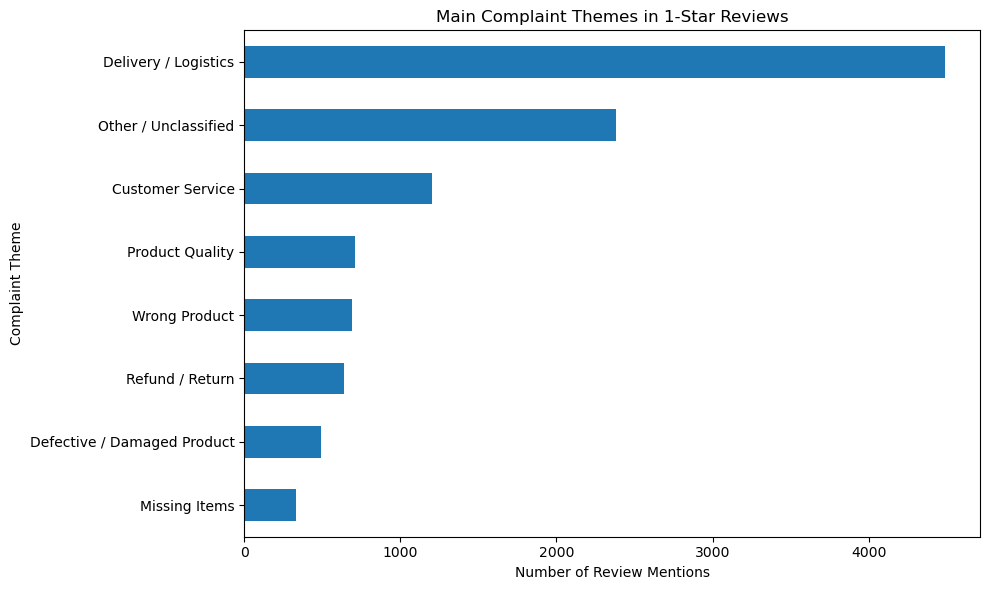

In [21]:
category_counts.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Main Complaint Themes in 1-Star Reviews")
plt.xlabel("Number of Review Mentions")
plt.ylabel("Complaint Theme")
plt.tight_layout()
plt.show()

### Finding

- Delivery and logistics issues are the dominant complaint theme in one-star reviews.

- Customer Service is the second most common complaint theme, suggesting that communication and post-purchase support are frequent concerns alongside delivery issues.

- Product Quality, Wrong Product, Refund / Return, Defective / Damaged Product, and Missing Items appear less frequently than delivery-related issues, but still represent meaningful operational themes.

- After filtering to reviews with written text and refining the Portuguese keyword dictionary, 2,379 one-star reviews remain unclassified.

- The remaining unclassified group shows the limitation of a rule-based keyword approach and highlights an opportunity for future NLP or machine learning classification.

## ⭐⭐⭐⭐⭐ 5-Star Reviews Analysis

### Business Question

What factors contribute most to customer satisfaction and positive customer experiences?

### Goal

- Identify common positive themes
- Determine what customers appreciate most
- Compare positive drivers against one-star complaints

In [22]:
five_star = reviews[reviews["review_score"] == 5].copy()

print(f"Total 5-star reviews: {len(five_star):,}")
print(f"With written comments: {(five_star['review_text'] != '').sum():,}")

five_star[
    ["order_id", "review_score", "review_text"]
].head(10)

Total 5-star reviews: 57,328
With written comments: 21,776


,order_id,review_score,review_text
1,a548910a1c6147796b98fdf73dbeba33,5,
2,f9e4b658b201a9f2ecdecbb34bed034b,5,
3,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa
6,e48aa0d2dcec3a2e87348811bcfdf22b,5,
7,c31a859e34e3adac22f376954e19b39d,5,
8,9c214ac970e84273583ab523dfafd09b,5,
10,cdf9aa68e72324eeb25c7de974696ee2,5,
11,3d374c9e46530bb5ed4a7648915306a6,5,
15,e51478e7e277a83743b6f9991dbfa3fb,5,"Super recomendo Vendedor confiável, produto ok e entrega antes do prazo."


### Manual Review of Positive Comments

In [23]:
five_star_comments = five_star[
    five_star["review_text"].str.strip() != ""
].copy()

five_star_comments[
    ["review_text"]
].sample(30, random_state=42)

,review_text
42526,Rápido e eficiente
94145,Entrega ok Recebi 12 dias antes da data fornecida.\r\nEu recomendo
47608,super recomendo ainda não usei mas chegou no prazo combinado
98569,"O produto foi entregue sem problema,só posso \r\n dizer se está certo depois que consultar o \r\n mecânico. obrigado."
6767,Ainda não utilizei as embalagens to aguardando a máquina chegar
4922,"Produto de Qualidade O produto em questão, apresenta boa qualidade o que consequentemente me leva a recomendar o mesmo."
21999,Produto de excelente qualidade. Superou minhas expectativas
24459,lannister show!@ Produto otimo muito pratico
20833,MT bom Entrega rápida parabéns!
77024,Bom


In [24]:
print(f"Total 5-star reviews: {len(five_star):,}")
print(f"5-star reviews with comments: {len(five_star_comments):,}")

Total 5-star reviews: 57,328
5-star reviews with comments: 21,776


In [25]:
sample_positive = five_star_comments.sample(
    20,
    random_state=42
)

for review in sample_positive["review_text"]:
    print(review)
    print("-" * 100)

Rápido e eficiente
----------------------------------------------------------------------------------------------------
Entrega ok Recebi 12 dias antes da data fornecida.
Eu recomendo
----------------------------------------------------------------------------------------------------
super recomendo ainda não usei mas chegou no prazo combinado
----------------------------------------------------------------------------------------------------
O produto foi entregue sem problema,só posso 
 dizer se está certo depois que consultar o 
 mecânico. obrigado.
----------------------------------------------------------------------------------------------------
Ainda não utilizei as embalagens to aguardando a máquina chegar
----------------------------------------------------------------------------------------------------
Produto de Qualidade  O produto em questão, apresenta boa qualidade o que consequentemente me leva a recomendar o mesmo.
------------------------------------------------------

In [26]:
positive_keywords = {

    "Fast Delivery":[
        "rápido",
        "rapido",
        "antes do prazo",
        "entrega rápida",
        "eficiente",
        "chegou no prazo",
"chegou antes",
"recebi antes",
"muito rápido",
"muito rapido",
"antes da data"
    ],

   "Product Quality":[
    "qualidade",
    "excelente",
    "ótimo",
    "otimo",
    "muito bom",
    "bom",
    "perfeito",
    "prático",
    "pratico",
    "superou",
    "expectativa"
],

    "Recommendation":[
        "recomendo",
        "super recomendo",
        "indico",
        "parabéns",
"parabens"
    ],

    "Correct Order":[
        "produto correto",
        "sem problemas",
        "tudo certo"
    ]
}

In [27]:
def classify_positive(text):

    text = str(text).lower()

    categories = []

    for category, keywords in positive_keywords.items():

        for keyword in keywords:

            if keyword in text:

                categories.append(category)

                break

    if categories:
        return ", ".join(categories)

    return "General Positive"

In [28]:
five_star_comments["positive_category"] = (
    five_star_comments["review_text"]
    .apply(classify_positive)
)

In [29]:
five_star_comments[
    ["review_text", "positive_category"]
].sample(20, random_state=42)

,review_text,positive_category
42526,Rápido e eficiente,Fast Delivery
94145,Entrega ok Recebi 12 dias antes da data fornecida.\r\nEu recomendo,"Fast Delivery, Recommendation"
47608,super recomendo ainda não usei mas chegou no prazo combinado,"Fast Delivery, Recommendation"
98569,"O produto foi entregue sem problema,só posso \r\n dizer se está certo depois que consultar o \r\n mecânico. obrigado.",General Positive
6767,Ainda não utilizei as embalagens to aguardando a máquina chegar,General Positive
4922,"Produto de Qualidade O produto em questão, apresenta boa qualidade o que consequentemente me leva a recomendar o mesmo.",Product Quality
21999,Produto de excelente qualidade. Superou minhas expectativas,Product Quality
24459,lannister show!@ Produto otimo muito pratico,Product Quality
20833,MT bom Entrega rápida parabéns!,"Fast Delivery, Product Quality, Recommendation"
77024,Bom,Product Quality


In [30]:
five_star_comments[
    ["review_text"]
].sample(50, random_state=7)

,review_text
43989,"super recomendado Recebi o produto correto, com prazo menor ao informado no ato da compra."
3873,"Entrega rápida antes do prazo, recomendo!"
83094,Recomendo!
20768,Do jeitinho descrito na propaganda. Eu recomendo.
26480,Excelente Ótimo vendedor. Atencioso e prestativo. O Sr. Bruno me atendeu de maneira gentil e eficiente. Recomendo.
84896,lannister sempre recomendo
61308,Bom.
59496,muito bom o preço acessivel
19313,"Excelente Entregue antes do prazo, com qualidade e como especificado na publicação.\r\nRecomendo."
9116,Ela é linda. Muito maior do que eu esperava.


In [31]:
positive_keywords_v2 = {
    "Fast Delivery": [
        "rápido", "rapido", "muito rápido", "muito rapido",
        "antes do prazo", "chegou antes", "chegou rápido", "chegou rapido",
        "entrega rápida", "entrega rapida", "entrega ok",
        "no prazo", "dentro do prazo", "prazo combinado",
        "eficiente", "pontual"
    ],

    "Product Quality": [
        "qualidade", "excelente", "ótimo", "otimo", "muito bom",
        "bom produto", "produto bom", "perfeito", "funciona",
        "superou minhas expectativas", "conforme anunciado",
        "produto ok", "correto", "satisfeito", "satisfeita"
    ],

    "Recommendation": [
        "recomendo", "super recomendo", "indicaria", "indico",
        "recomendaria", "recomendar", "comprarei novamente",
        "compraria novamente"
    ],

    "Customer Service": [
        "atendimento", "atencioso", "atenciosa", "prestativo",
        "prestativa", "resolveram", "solucionaram", "suporte",
        "resposta rápida", "resposta rapida"
    ],

    "Value for Money": [
        "preço", "preco", "barato", "vale a pena",
        "custo benefício", "custo beneficio", "bom preço", "bom preco"
    ],

    "Packaging": [
        "embalagem", "bem embalado", "bem embalada",
        "embalado", "embalada", "proteção", "protecao"
    ]
}

In [32]:
def classify_positive_v2(text):
    text = str(text).lower()
    categories = []

    for category, keywords in positive_keywords_v2.items():
        for keyword in keywords:
            if keyword in text:
                categories.append(category)
                break

    if categories:
        return ", ".join(categories)

    return "Other Positive"

In [33]:
five_star_comments["positive_category_v2"] = (
    five_star_comments["review_text"]
    .apply(classify_positive_v2)
)

five_star_comments[
    ["review_text", "positive_category_v2"]
].sample(30, random_state=42)

,review_text,positive_category_v2
42526,Rápido e eficiente,Fast Delivery
94145,Entrega ok Recebi 12 dias antes da data fornecida.\r\nEu recomendo,"Fast Delivery, Recommendation"
47608,super recomendo ainda não usei mas chegou no prazo combinado,"Fast Delivery, Recommendation"
98569,"O produto foi entregue sem problema,só posso \r\n dizer se está certo depois que consultar o \r\n mecânico. obrigado.",Other Positive
6767,Ainda não utilizei as embalagens to aguardando a máquina chegar,Other Positive
4922,"Produto de Qualidade O produto em questão, apresenta boa qualidade o que consequentemente me leva a recomendar o mesmo.","Product Quality, Recommendation"
21999,Produto de excelente qualidade. Superou minhas expectativas,Product Quality
24459,lannister show!@ Produto otimo muito pratico,Product Quality
20833,MT bom Entrega rápida parabéns!,Fast Delivery
77024,Bom,Other Positive


In [34]:
positive_category_counts = (
    five_star_comments["positive_category_v2"]
    .str.split(", ")
    .explode()
    .value_counts()
)

positive_category_counts

positive_category_v2
Product Quality     10404
Fast Delivery        7213
Other Positive       5601
Recommendation       4821
Packaging             782
Customer Service      604
Value for Money       555
Name: count, dtype: int64

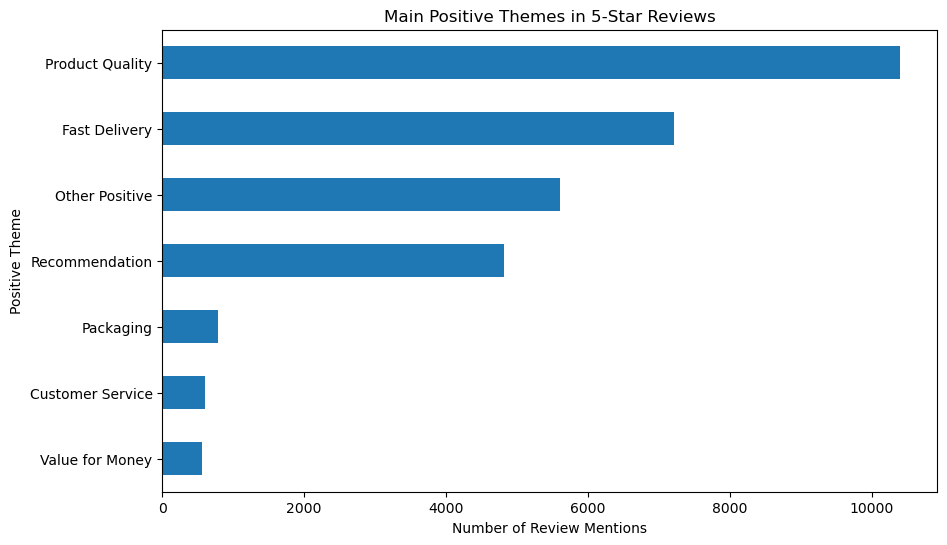

In [35]:
import matplotlib.pyplot as plt

positive_category_counts.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Main Positive Themes in 5-Star Reviews")
plt.xlabel("Number of Review Mentions")
plt.ylabel("Positive Theme")
plt.show()

### Finding

The strongest positive themes in five-star reviews are product quality, fast delivery, and customer recommendation.

This suggests that customers reward the business most when products meet expectations, arrive quickly, and create enough confidence for customers to recommend the store.

The "Other Positive" group remains meaningful because many five-star comments are very short, such as "good", "ok", or "great", and do not always contain enough detail for precise keyword classification.

## ⭐⭐⭐⭐ Mixed Reviews Analysis (2–4 Stars)

Business Question

What prevents customers from having an excellent shopping experience despite leaving a moderate review?

Goal

Identify common improvement opportunities
Detect recurring issues among moderate reviews
Understand what separates average experiences from excellent ones

In [36]:
mixed_reviews = reviews[
    reviews["review_score"].isin([2, 3, 4])
].copy()

print(f"Total 2-4 star reviews: {len(mixed_reviews):,}")

Total 2-4 star reviews: 30,472


In [37]:
mixed_comments = mixed_reviews[
    mixed_reviews["review_text"].str.strip() != ""
].copy()

print(f"2-4 star reviews with comments: {len(mixed_comments):,}")

2-4 star reviews with comments: 12,082


In [38]:
mixed_comments[
    ["review_text"]
].sample(
    50,
    random_state=12
)

,review_text
43019,"otimo veio muito rápido, recomendo"
88828,sempre compro e nao tenho reclamações \r\n\r\nchato tem q avalir em 160 caracteres heim?????????????????????????????????????????????????????????????????????????????????????????????????????????????????????
28292,"O produto entregue chegou diferente do produto ilustrado na foto do site, induzindo ao erro na compra. Estou tentando devolver no site, porém não finaliza o processo, quando tento dar continuidade."
6580,sem maiores problemas
73175,Bom Dentro do prazo\r\nProduto bom
3348,"O produto não é de boa qualidade, e seu resultado não é o esperado! Acho que perdi dinheiro."
19698,"APAGADO FICA ESTRANHO, MAS LIGADO FICOU BONITO."
96722,Boa qualidade e entregue no tempo certo...
7639,bom produto razoável
66010,Demora pra entregar.


In [39]:
mixed_keywords = {

    "Delivery":[
        "entrega",
        "prazo",
        "atraso",
        "atrasada",
        "atrasado",
        "demora",
        "demorou",
        "não chegou",
        "nao chegou",
        "recebi",
        "chegou"
    ],

    "Product Quality":[
        "qualidade",
        "bom",
        "ótimo",
        "otimo",
        "excelente",
        "perfeito",
        "funciona",
        "frágil",
        "fragil",
        "acabamento"
    ],

    "Wrong Product":[
        "diferente",
        "cor errada",
        "cor preta",
        "cor vermelha",
        "descrição",
        "descricao",
        "anúncio",
        "anuncio"
    ],

    "Defective Product":[
        "defeito",
        "defeito",
        "quebrado",
        "riscado",
        "danificado",
        "não funciona",
        "nao funciona"
    ],

    "Customer Service":[
        "atendimento",
        "resposta",
        "contato",
        "cancelado",
        "cancelamento",
        "orientação",
        "orientacao"
    ],

    "Return / Refund":[
        "troca",
        "devolver",
        "devolução",
        "devolucao",
        "cancelar"
    ],

    "Value for Money":[
        "preço",
        "preco",
        "valor",
        "caro",
        "barato"
    ],

    "Packaging":[
        "embalagem",
        "embalado",
        "embalada"
    ],

    "Product Functionality":[
        "manual",
        "instalado",
        "instalar",
        "funciona",
        "ligado"
    ],
    "Product Description":[
    "descrição",
    "descricao",
    "foto",
    "imagem",
    "site",
    "anúncio",
    "anuncio",
    "mostra"
]
}

In [40]:
def classify_mixed(text):

    text = str(text).lower()

    categories = []

    for category, keywords in mixed_keywords.items():

        for keyword in keywords:

            if keyword in text:

                categories.append(category)

                break

    if categories:

        return ", ".join(categories)

    return "Other Mixed"

In [41]:
mixed_comments["mixed_category"] = (
    mixed_comments["review_text"]
    .apply(classify_mixed)
)

In [42]:
mixed_comments[
    ["review_text","mixed_category"]
].sample(
    25,
    random_state=42
)

,review_text,mixed_category
42272,"Bons produto, como o combinado.",Other Mixed
57441,"bom produto bom produto,estou sastifeito com o produto eu recomendo.",Product Quality
14242,"Bom Demorou para chega, porém no último dia do prazo.\r\nGostei da gualidade do produto","Delivery, Product Quality"
11874,Bom !,Product Quality
16987,"A data de entrega do produto era até 6 de dezembro e o produto chegou no dia 22/11/2017, bem adiantada.",Delivery
7468,Produto chegou mais rápido que o esperado e de ótima qualidade.,"Delivery, Product Quality"
3654,recomendo Demorou um pouco a entrega mais fui avisada e no mais tudo certo o produto chegou e gostei.,Delivery
93838,"A garrafa é muito pequena, não acredito que tem 1,2 litros conforme mencionada na embalagem e no anúncio.\r\nNão recomendo a compra do produto.","Wrong Product, Packaging, Product Description"
71882,Recomendo Já comprei outras vezes e fui bem atendido.,Other Mixed
20937,São dois produtos só recebi um é sem nota,Delivery


In [43]:
mixed_counts = (
    mixed_comments["mixed_category"]
    .str.split(", ")
    .explode()
    .value_counts()
)

mixed_counts

mixed_category
Delivery                 5266
Product Quality          3503
Other Mixed              3368
Product Description       813
Wrong Product             478
Value for Money           470
Return / Refund           397
Packaging                 394
Customer Service          373
Defective Product         311
Product Functionality     309
Name: count, dtype: int64

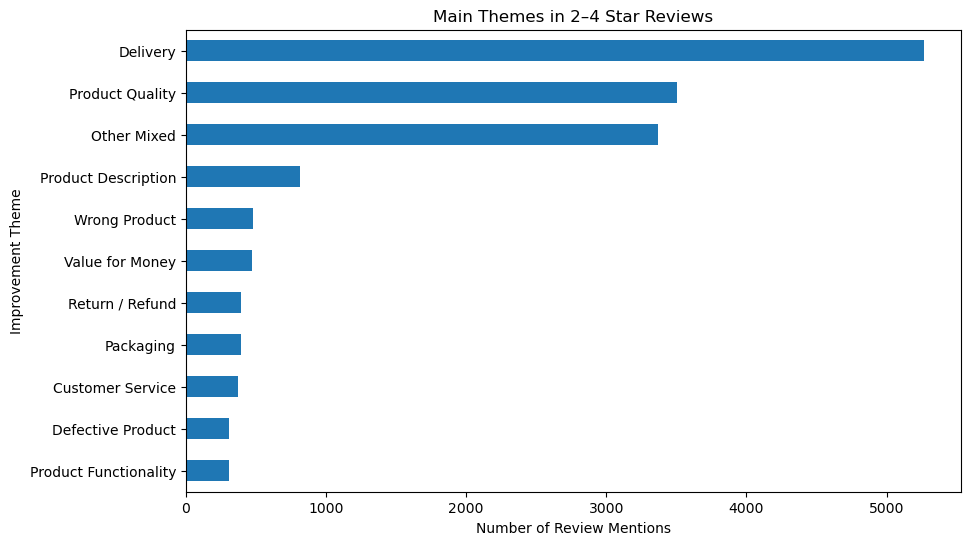

In [44]:
mixed_counts.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Main Themes in 2–4 Star Reviews")
plt.xlabel("Number of Review Mentions")
plt.ylabel("Improvement Theme")

plt.show()

### Finding

Most moderate reviews reflect customers who were generally satisfied with their purchase but experienced one or more friction points.

The most common opportunities for improvement involve delivery reliability, clearer communication, product expectations, and overall product quality.

Addressing these recurring issues could convert many moderate reviews into five-star customer experiences.

## * Business Recommendations *

Based on the review analysis, the strongest operational opportunity is improving delivery reliability and post-purchase communication.

### 1. Improve delivery reliability
Delivery and logistics issues were the dominant theme in one-star reviews and also appeared in moderate reviews.

Recommended actions:
- Monitor late delivery rates by seller, carrier, product category, and region.
- Flag orders approaching estimated delivery deadlines.
- Improve proactive delivery updates when delays occur.

### 2. Strengthen customer service communication
Customer service appeared frequently alongside delivery complaints, suggesting that customers become more dissatisfied when delivery issues are not clearly explained or resolved.

Recommended actions:
- Create automated support messages for delayed, missing, or returned orders.
- Prioritize support tickets linked to one-star reviews.
- Track response time and resolution time as customer experience KPIs.

### 3. Reduce product expectation gaps
Wrong product, product quality, damaged product, and missing item complaints suggest issues in product listing accuracy, fulfillment, and packaging.

Recommended actions:
- Audit product listings with repeated complaint keywords.
- Review seller quality for wrong-item and defective-product complaints.
- Strengthen packaging controls for fragile or damage-prone products.

### 4. Protect what customers already value
Five-star reviews show that customers strongly reward product quality, fast delivery, and smooth purchase experiences.

Recommended actions:
- Use fast delivery and reliable fulfillment as key customer experience differentiators.
- Identify sellers/products with high five-star feedback and replicate their practices.
- Promote products with consistent quality and delivery performance.

## Final Conclusion

The review data shows that customer satisfaction is strongly connected to operational execution. Customers reward fast delivery, product quality, and reliable order fulfillment, while dissatisfaction is mainly driven by delivery failures, communication gaps, and product expectation issues.

The analysis suggests that improving logistics visibility, strengthening customer service workflows, and monitoring seller/product quality could reduce negative reviews and convert more moderate experiences into five-star outcomes.

## Limitations and Next Steps

This analysis uses a rule-based keyword classifier on Portuguese review text. The results should be interpreted as directional business insight rather than perfect classification.

Future improvements could include:
- Translating review text into English for broader stakeholder review.
- Applying NLP topic modeling or sentiment analysis.
- Validating classifier accuracy with a manually labeled sample.
- Joining reviews with orders, products, sellers, and delivery data to identify specific root causes.